In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import shap

BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..'))

# Load model and vectorizer
svm = joblib.load(os.path.join(BASE_DIR, "models", "svm_tfidf.pkl"))
vectorizer = joblib.load(os.path.join(BASE_DIR, "models", "tfidf_vectorizer.pkl"))

# Load test data
test = pd.read_csv(os.path.join(BASE_DIR, "data", "processed", "test_classical.csv"))
print(f"Test samples: {len(test)}")
print(f"Classes: {svm.classes_}")

Test samples: 4031
Classes: ['cancel_order' 'change_order' 'change_shipping_address'
 'check_cancellation_fee' 'check_invoice' 'check_payment_methods'
 'check_refund_policy' 'complaint' 'contact_customer_service'
 'contact_human_agent' 'create_account' 'delete_account'
 'delivery_options' 'delivery_period' 'edit_account' 'get_invoice'
 'get_refund' 'newsletter_subscription' 'payment_issue' 'place_order'
 'recover_password' 'registration_problems' 'review'
 'set_up_shipping_address' 'switch_account' 'track_order' 'track_refund']


In [2]:
# Use a background sample for SHAP
train = pd.read_csv(os.path.join(BASE_DIR, "data", "processed", "train_classical.csv"))

# Transform text to TF-IDF features
X_train = vectorizer.transform(train['text_clean'])
X_test = vectorizer.transform(test['text_clean'])

# Use 500 background samples for efficiency
background = shap.sample(X_train, 500, random_state=42)

# Create explainer
explainer = shap.LinearExplainer(svm, background, feature_perturbation="interventional")
print("SHAP explainer created successfully")

c:\Users\HP\Desktop\customer-support-nlp-agent\venv\Lib\site-packages\shap\explainers\_linear.py:123: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)
Background dataset has 500 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=500 when initializing the masker.


SHAP explainer created successfully


In [3]:
# Use 200 test samples (full test set is slow)
X_test_sample = X_test[:200]
test_sample = test.iloc[:200]

print("Computing SHAP values (this takes 1-2 minutes)...")
shap_values = explainer.shap_values(X_test_sample)

print(f"SHAP values shape: {np.array(shap_values).shape}")
print("Done!")

Computing SHAP values (this takes 1-2 minutes)...
SHAP values shape: (200, 3858, 27)
Done!


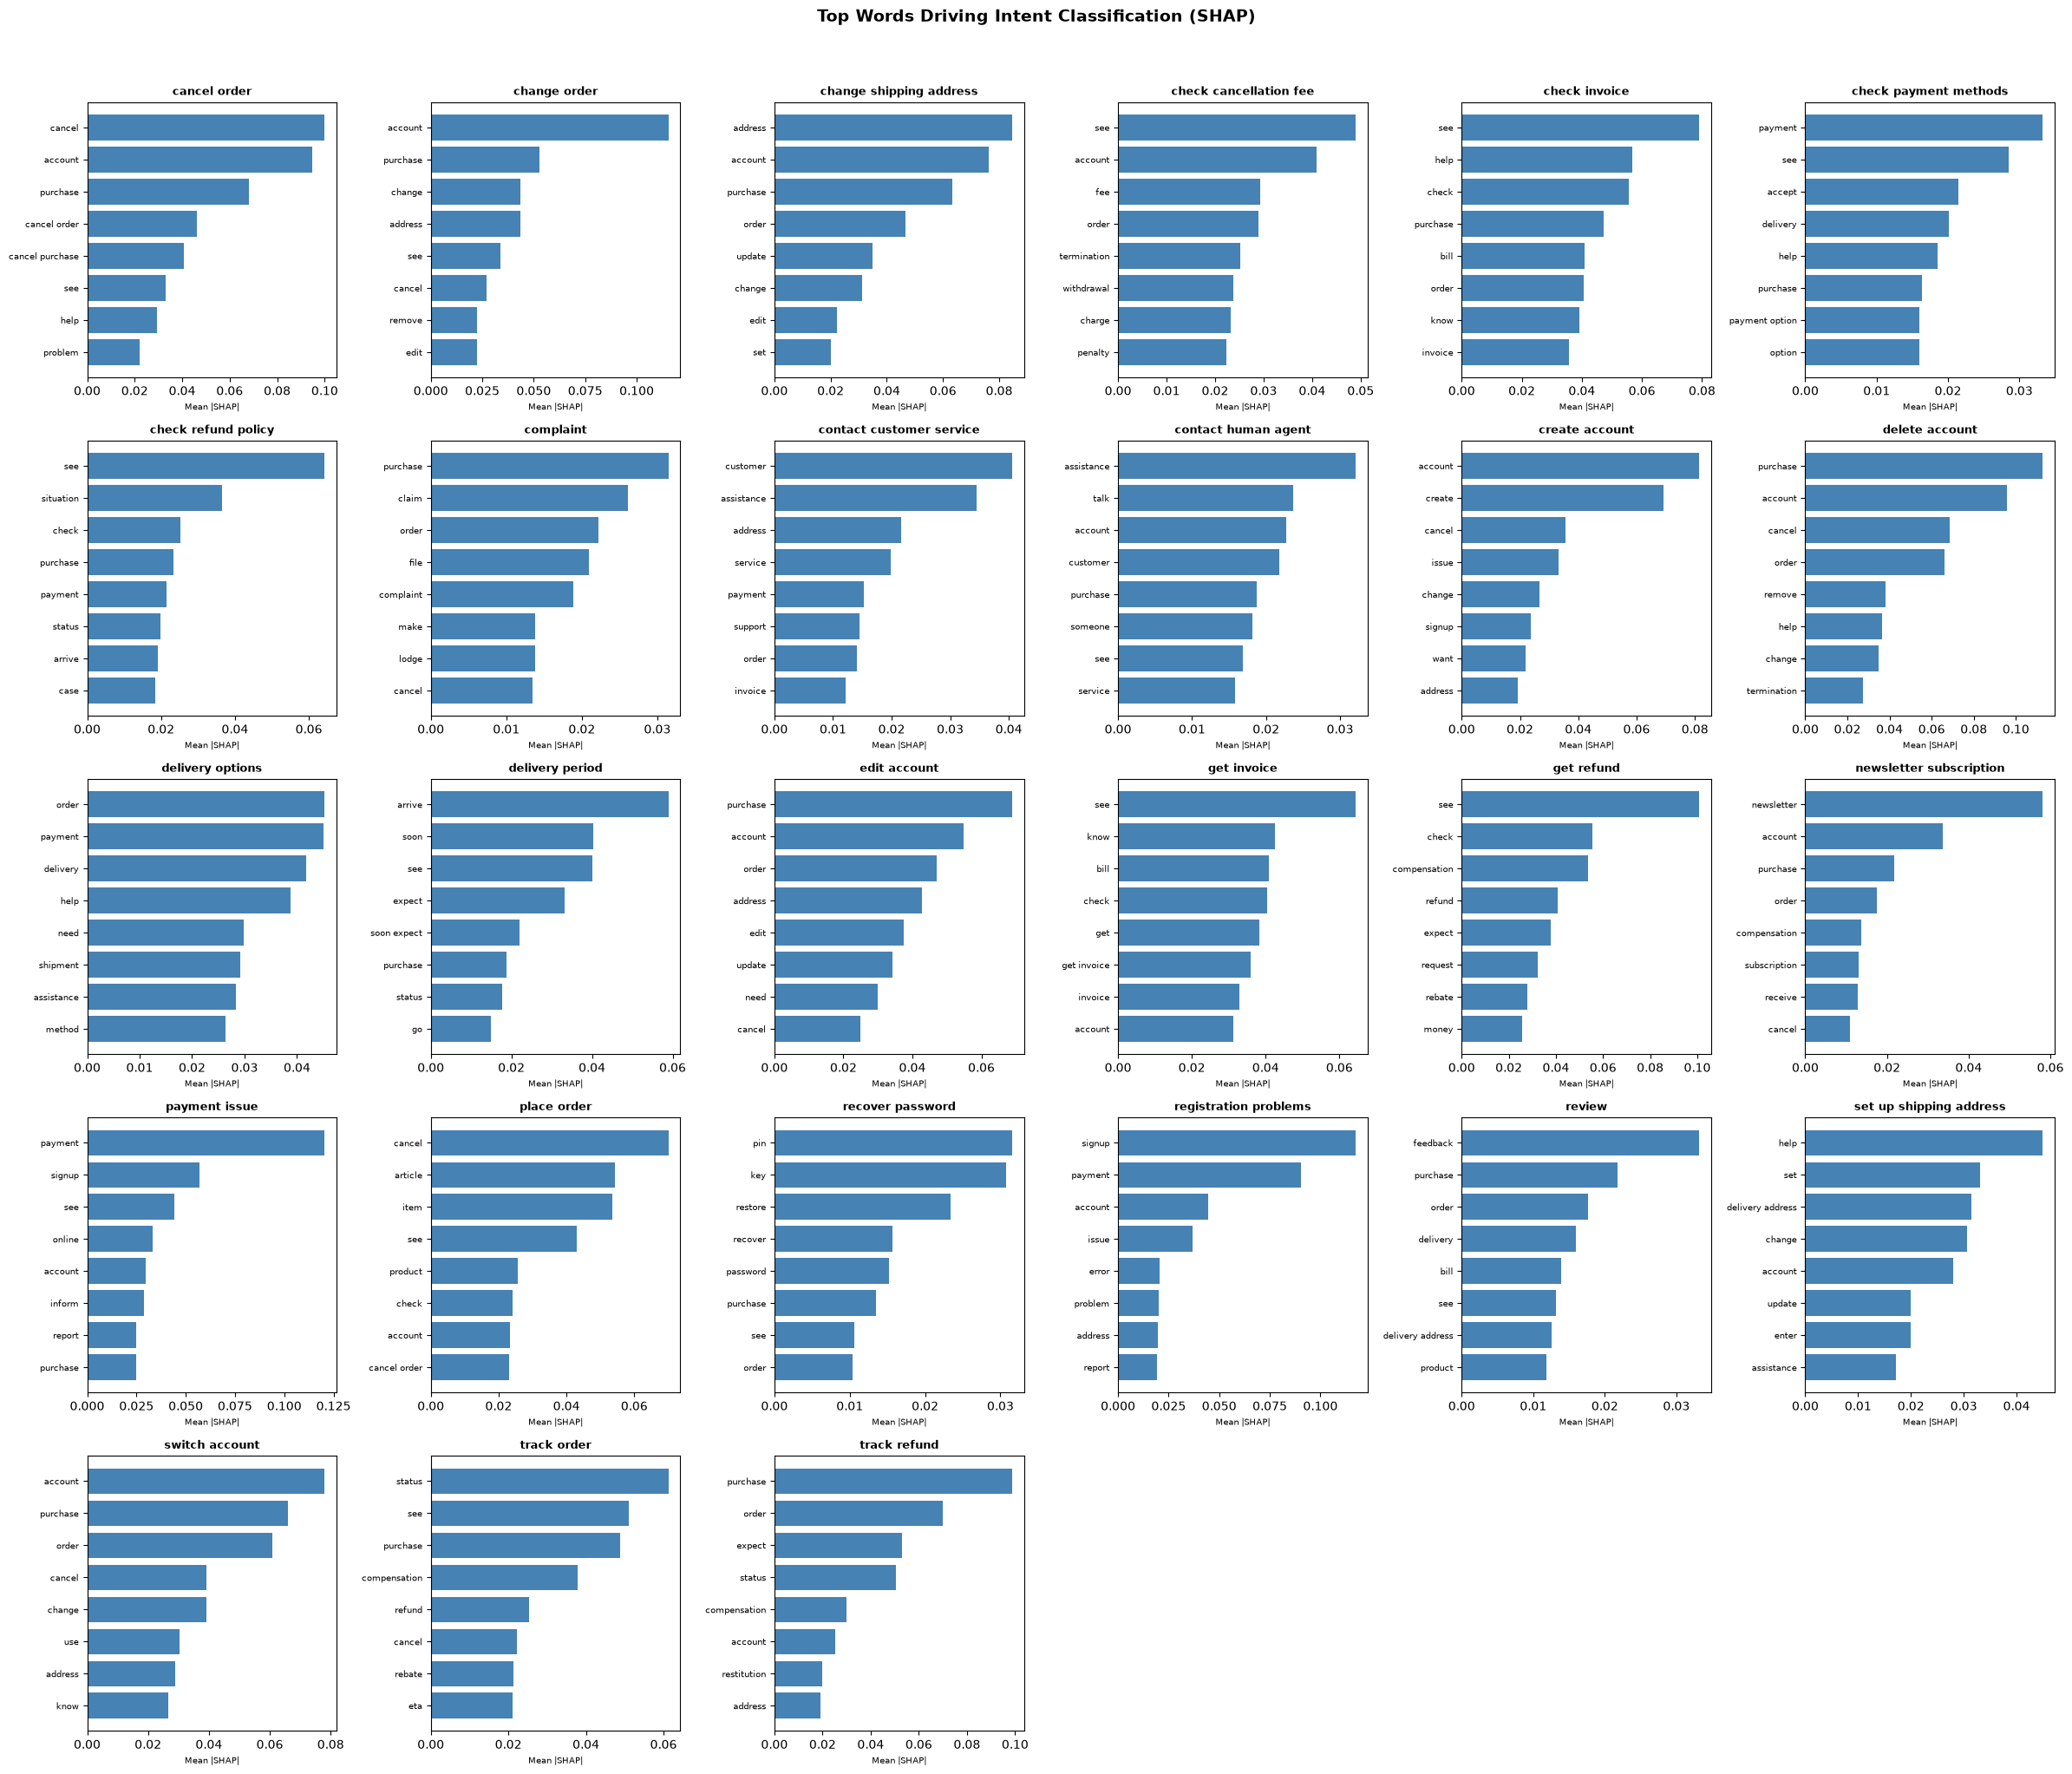

SHAP plot saved to models/shap_intent_words.png


In [8]:
feature_names = vectorizer.get_feature_names_out()
classes = svm.classes_

fig, axes = plt.subplots(5, 6, figsize=(24, 20))
axes = axes.flatten()

for idx, intent in enumerate(classes):
    if idx >= len(axes):
        break
    
    # Get mean absolute SHAP values for this class
    class_idx = list(classes).index(intent)
    mean_shap = np.abs(shap_values[:, :, class_idx]).mean(axis=0)
    
    # Top 8 features
    top_indices = mean_shap.argsort()[-8:][::-1]
    top_features = [feature_names[i] for i in top_indices]
    top_values = mean_shap[top_indices]
    
    axes[idx].barh(top_features[::-1], top_values[::-1], color='steelblue')
    axes[idx].set_title(intent.replace('_', ' '), fontsize=9, fontweight='bold')
    axes[idx].set_xlabel('Mean |SHAP|', fontsize=7)
    axes[idx].tick_params(axis='y', labelsize=7)

# Hide unused subplots
for idx in range(len(classes), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Top Words Driving Intent Classification (SHAP)', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'models', 'shap_intent_words.png'), 
            dpi=150, bbox_inches='tight')
plt.show()
print("SHAP plot saved to models/shap_intent_words.png")

In [7]:
# Debug cell - run this first
import re
text = "where is my refund I have been waiting"
cleaned = text.lower()
cleaned = re.sub(r'[^a-z\s]', '', cleaned)

X = vectorizer.transform([cleaned])
pred = svm.predict(X)[0]
print(f"Predicted: {pred}")
print(f"Class index: {list(classes).index(pred)}")

shap_val = explainer.shap_values(X)
shap_array = np.array(shap_val)

print(f"shap_val type: {type(shap_val)}")
print(f"shap_array shape: {shap_array.shape}")
print(f"shap_array ndim: {shap_array.ndim}")
if isinstance(shap_val, list):
    print(f"shap_val list length: {len(shap_val)}")
    print(f"shap_val[0] shape: {np.array(shap_val[0]).shape}")

Predicted: get_refund
Class index: 16
shap_val type: <class 'numpy.ndarray'>
shap_array shape: (1, 3858, 27)
shap_array ndim: 3


In [9]:
def explain_prediction(text, true_label=None):
    import re
    cleaned = text.lower()
    cleaned = re.sub(r'[^a-z\s]', '', cleaned)
    
    X = vectorizer.transform([cleaned])
    pred = svm.predict(X)[0]
    
    shap_val = explainer.shap_values(X)
    shap_array = np.array(shap_val)
    
    # Shape is (n_samples, n_features, n_classes)
    class_idx = list(classes).index(pred)
    
    # Get shap values: sample 0, all features, predicted class
    instance_shap = shap_array[0, :, class_idx]
    
    # Top positive and negative words
    top_pos_idx = instance_shap.argsort()[-5:][::-1]
    top_neg_idx = instance_shap.argsort()[:5]
    
    print(f"Text: '{text}'")
    print(f"Predicted: {pred}")
    if true_label:
        print(f"True label: {true_label}")
    print(f"\nWords pushing TOWARD '{pred}':")
    for i in top_pos_idx:
        if instance_shap[i] > 0:
            print(f"  '{feature_names[i]}': +{instance_shap[i]:.4f}")
    print(f"\nWords pushing AWAY from '{pred}':")
    for i in top_neg_idx:
        if instance_shap[i] < 0:
            print(f"  '{feature_names[i]}': {instance_shap[i]:.4f}")

# Run the tests
explain_prediction("I want to cancel my order please")
print("\n" + "="*50 + "\n")
explain_prediction("where is my refund I have been waiting")
print("\n" + "="*50 + "\n")
explain_prediction("I cannot log into my account")

Text: 'I want to cancel my order please'
Predicted: cancel_order

Words pushing TOWARD 'cancel_order':
  'cancel': +1.2135
  'order': +0.1531
  'want': +0.0895
  'account': +0.0471
  'see': +0.0182

Words pushing AWAY from 'cancel_order':
  'cancel order': -0.0310
  'purchase': -0.0259
  'to': -0.0163
  'help': -0.0159
  'problem': -0.0155


Text: 'where is my refund I have been waiting'
Predicted: get_refund

Words pushing TOWARD 'get_refund':
  'refund': +2.2616
  'see': +0.0559
  'check': +0.0382
  'expect': +0.0180
  'bill': +0.0151

Words pushing AWAY from 'get_refund':
  'compensation': -0.0388
  'request': -0.0206
  'rebate': -0.0141
  'know': -0.0132
  'reimbursement': -0.0132


Text: 'I cannot log into my account'
Predicted: delete_account

Words pushing TOWARD 'delete_account':
  'account': +1.8666
  'purchase': +0.0430
  'order': +0.0352
  'help': +0.0196
  'create': +0.0160

Words pushing AWAY from 'delete_account':
  'cancel': -0.0285
  'termination': -0.0198
  'not': -0.0

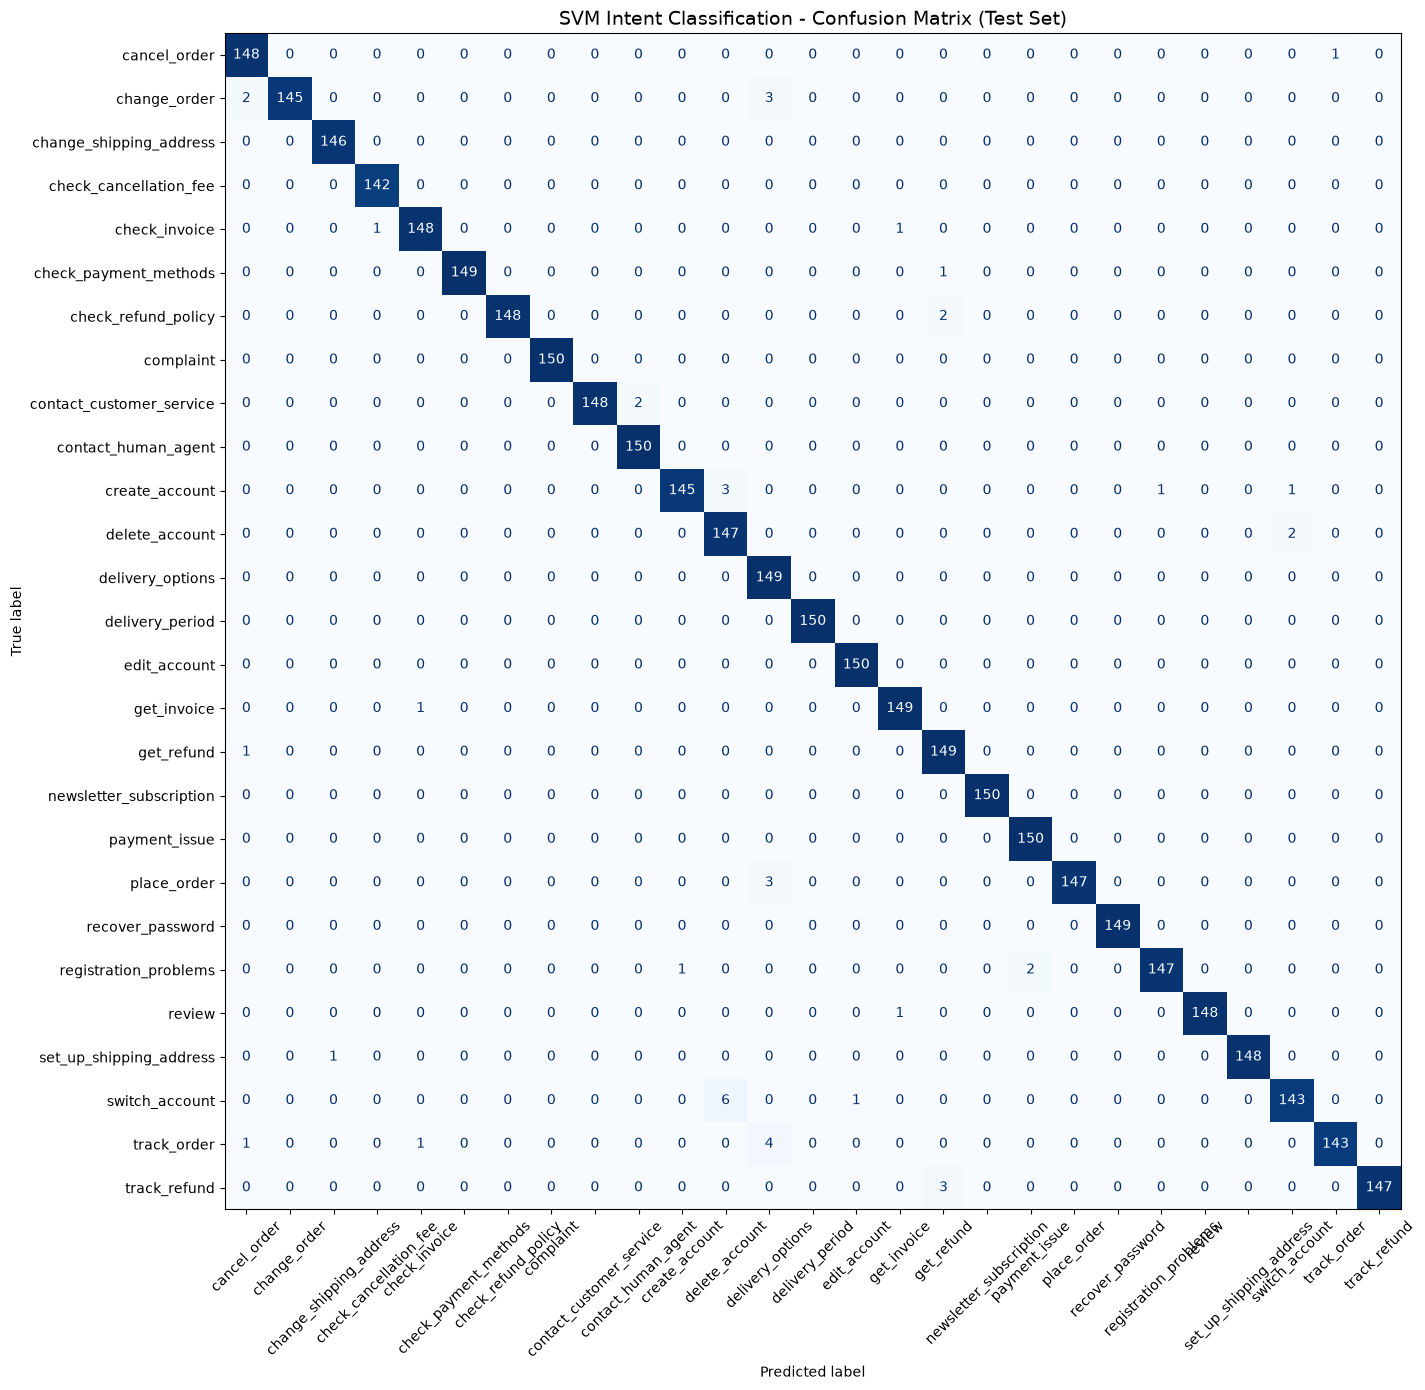

Confusion matrix saved


In [10]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

y_test = test['label']
y_pred = svm.predict(X_test)

cm = confusion_matrix(y_test, y_pred, labels=svm.classes_)
fig, ax = plt.subplots(figsize=(18, 14))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=svm.classes_)
disp.plot(ax=ax, xticks_rotation=45, colorbar=False, cmap='Blues')
plt.title("SVM Intent Classification - Confusion Matrix (Test Set)", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'models', 'confusion_matrix.png'), 
            dpi=150, bbox_inches='tight')
plt.show()
print("Confusion matrix saved")

In [11]:
from sklearn.metrics import classification_report
import json

report = classification_report(y_test, y_pred, output_dict=True)

summary = {
    "baseline_models": {
        "svm_tfidf": {"val_accuracy": 0.9893},
        "naive_bayes": {"val_accuracy": 0.9883},
        "logistic_regression": {"val_accuracy": 0.9873}
    },
    "distilbert": {
        "val_accuracy": 0.9985,
        "test_accuracy": 0.9975
    },
    "svm_test_report": report
}

with open(os.path.join(BASE_DIR, 'models', 'evaluation_summary.json'), 'w') as f:
    json.dump(summary, f, indent=2)

print("Evaluation summary saved to models/evaluation_summary.json")
print(f"\nSVM Test Accuracy: {report['accuracy']:.4f}")
print(f"Macro F1: {report['macro avg']['f1-score']:.4f}")

Evaluation summary saved to models/evaluation_summary.json

SVM Test Accuracy: 0.9886
Macro F1: 0.9886
